In [3]:
# ProcessedDataPath = './processed_adata.h5ad'
ProcessedDataPath = '/Users/baixuezhang/Documents/SJSU/study/CS271/CS271-Project/processed_adata.h5ad'

In [4]:
import anndata as ad

adata = ad.read_h5ad(ProcessedDataPath)
adata

AnnData object with n_obs × n_vars = 21412 × 18080
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_umap'

In [7]:
adata.var['highly_variable'].unique()

array([ True])

In [6]:
adata = adata[:, adata.var['highly_variable']].copy()
adata

AnnData object with n_obs × n_vars = 21412 × 3051
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_umap'

In [8]:
adata.obs['target_gene'].unique()

['EIF4B', 'DAXX', 'METTL3', 'non-targeting', 'MBTPS1', ..., 'MED24', 'SUPT4H1', 'ATP6V0C', 'RRM1', 'HMGCR']
Length: 69
Categories (69, object): ['ARPC2', 'ATP6V0B', 'ATP6V0C', 'C1QBP', ..., 'UQCRQ', 'USF2', 'WAC', 'non-targeting']

In [9]:
ControlData = adata[adata.obs['target_gene'] == 'non-targeting'].copy()
ControlData

AnnData object with n_obs × n_vars = 12013 × 3051
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_umap'

In [10]:
ControlData.obs['target_gene'].unique()

['non-targeting']
Categories (1, object): ['non-targeting']

In [12]:
PertubatedData = adata[adata.obs['target_gene'] != 'non-targeting'].copy()
PertubatedData

AnnData object with n_obs × n_vars = 9399 × 3051
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_umap'

In [13]:
PertubatedData.obs['target_gene'].unique()

['EIF4B', 'DAXX', 'METTL3', 'MBTPS1', 'SDC1', ..., 'MED24', 'SUPT4H1', 'ATP6V0C', 'RRM1', 'HMGCR']
Length: 68
Categories (68, object): ['ARPC2', 'ATP6V0B', 'ATP6V0C', 'C1QBP', ..., 'UQCRB', 'UQCRQ', 'USF2', 'WAC']

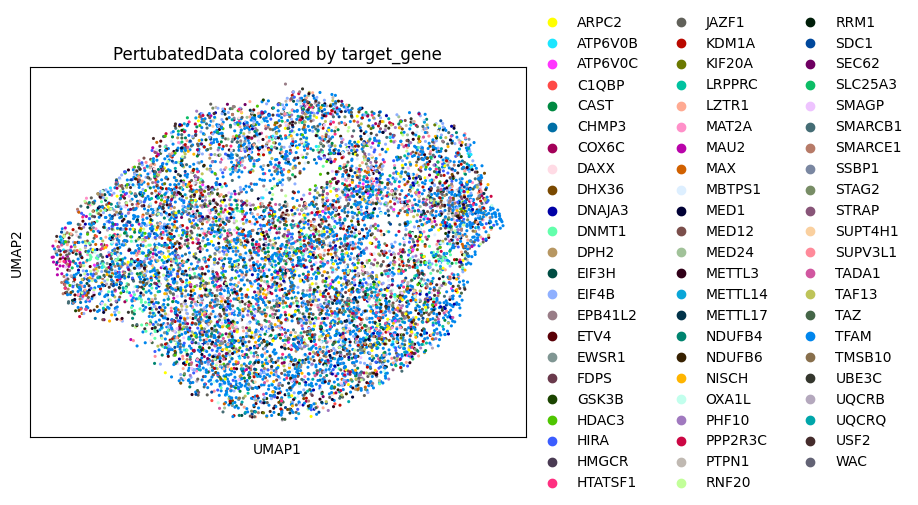

In [14]:
import scanpy as sc

sc.pl.umap(PertubatedData, color='target_gene', legend_loc='right margin', size=20,
           title='PertubatedData colored by target_gene')

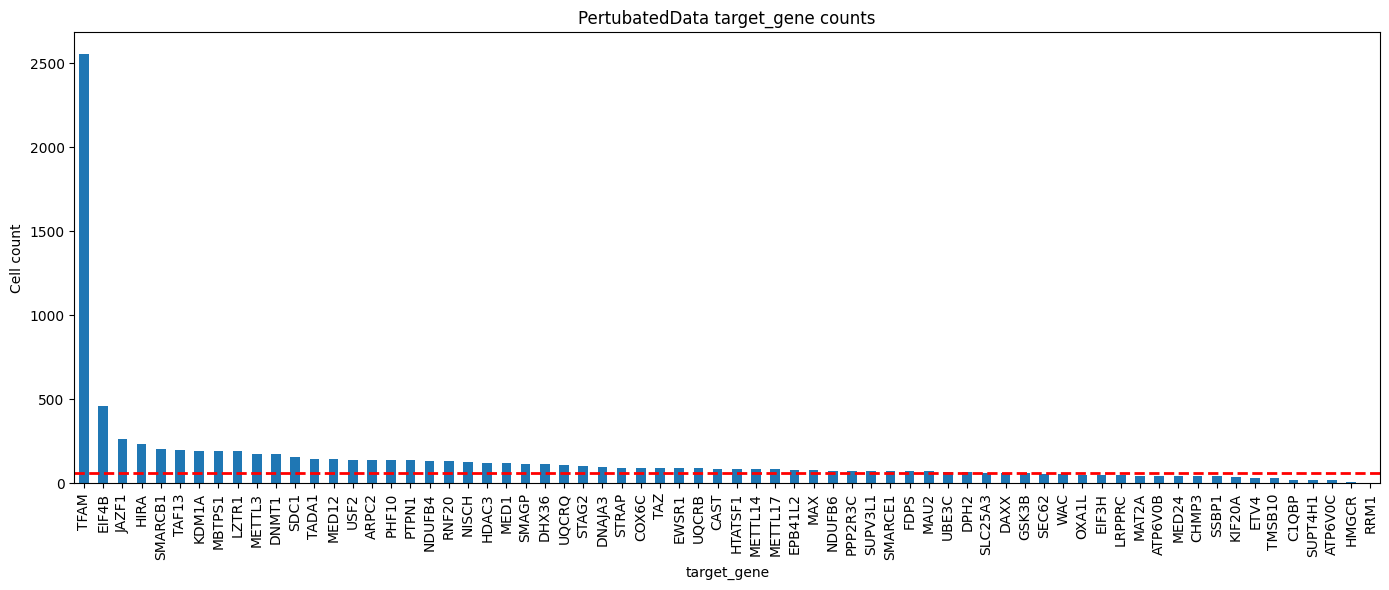

In [20]:
import matplotlib.pyplot as plt

# target_counts = PertubatedData.obs['target_gene'].value_counts().sort_index()
target_counts = PertubatedData.obs['target_gene'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
target_counts.plot(kind='bar')
plt.axhline(y=60, color='red', linestyle='--', linewidth=2, label='y = 100')
plt.title('PertubatedData target_gene counts')
plt.xlabel('target_gene')
plt.ylabel('Cell count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
print("ControlData observations:", ControlData.n_obs)
print("PertubatedData observations:", PertubatedData.n_obs)

ControlData observations: 12013
PertubatedData observations: 9399


In [26]:
import numpy as np

# One-hot vector by target count rank
pertabation = np.zeros(len(target_counts), dtype=int)
pertabation[0] = 1  # highest cell count position in the sorted target_counts

PertubatedData.uns['pertabation'] = pertabation
PertubatedData.uns['pertabation_target_order'] = target_counts.index.tolist()

pertabation


array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [ ]:
# Sanity check: Verify that the pertabation vector is correctly assigned to the PertubatedData
import numpy as np

def sanity_check_perturbation(target_counts, PertubatedData):
    errors = []


    # 1️⃣ 基本类型检查
    if not hasattr(target_counts, "index"):
        errors.append("target_counts must be a pandas Series with index")

    if not isinstance(PertubatedData.uns.get('pertabation'), np.ndarray):
        errors.append("pertabation must be a numpy array")

    pertabation = PertubatedData.uns.get('pertabation')
    target_order = PertubatedData.uns.get('pertabation_target_order')

    # 2️⃣ 长度一致性
    if len(pertabation) != len(target_counts):
        errors.append("Length mismatch between pertabation and target_counts")

    # 3️⃣ one-hot 检查
    if np.sum(pertabation) != 1:
        errors.append("pertabation is not one-hot (sum != 1)")

    if not set(pertabation).issubset({0, 1}):
        errors.append("pertabation contains values other than 0/1")

    # 4️⃣ 顺序一致性
    if list(target_counts.index) != target_order:
        errors.append("target order mismatch between stored order and target_counts.index")

    # 5️⃣ 最大值位置检查（核心 sanity check）
    true_max_idx = np.argmax(target_counts.values)
    marked_idx = np.argmax(pertabation)

    if true_max_idx != marked_idx:
        errors.append(
            f"Mismatch: marked index {marked_idx} is not the max count index {true_max_idx}"
        )

    # 6️⃣ 是否真的排序了（可选但很重要）
    if not np.all(target_counts.values[:-1] >= target_counts.values[1:]):
        errors.append("target_counts is not sorted in descending order")

    # ✅ 输出结果
    if len(errors) == 0:
        print("✅ Sanity check passed!")
    else:
        print("❌ Sanity check failed:")
        for e in errors:
            print(" -", e)

    return errors

# 运行 sanity check
sanity_check_perturbation(target_counts, PertubatedData)

✅ Sanity check passed!


[]

In [21]:
high_count_genes = target_counts[target_counts > 60]
high_count_genes

target_gene
TFAM       2555
EIF4B       461
JAZF1       265
HIRA        233
SMARCB1     204
TAF13       200
KDM1A       195
MBTPS1      192
LZTR1       192
METTL3      177
DNMT1       177
SDC1        156
TADA1       144
MED12       143
USF2        141
ARPC2       140
PHF10       136
PTPN1       136
NDUFB4      133
RNF20       131
NISCH       127
HDAC3       120
MED1        120
SMAGP       115
DHX36       113
UQCRQ       112
STAG2       101
DNAJA3       99
STRAP        94
COX6C        92
TAZ          92
EWSR1        89
UQCRB        89
CAST         88
HTATSF1      88
METTL14      87
METTL17      83
EPB41L2      79
MAX          78
NDUFB6       76
PPP2R3C      76
SUPV3L1      76
SMARCE1      73
FDPS         72
MAU2         72
UBE3C        70
DPH2         68
SLC25A3      63
DAXX         62
GSK3B        61
Name: count, dtype: int64

In [22]:
len(high_count_genes)

50

In [23]:
import numpy as np

rng = np.random.default_rng(42)
high_count_targets = set(high_count_genes.index)

high_count_mask = PertubatedData.obs['target_gene'].isin(high_count_targets)
high_count_obs = PertubatedData.obs_names[high_count_mask]

sample_size = max(1, int(np.ceil(len(high_count_obs) * 0.1)))
sampled_obs = rng.choice(high_count_obs, size=sample_size, replace=False)

ValidationData = PertubatedData[sampled_obs].copy()
ValidationData

AnnData object with n_obs × n_vars = 875 × 3051
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'target_gene_colors'
    obsm: 'X_umap'

In [24]:
rest_data = PertubatedData[~PertubatedData.obs_names.isin(ValidationData.obs_names)].copy()

rest_high_count_targets = list(high_count_targets)
n_test_targets = max(1, int(np.ceil(len(rest_high_count_targets) * 0.1)))

test_targets = rng.choice(rest_high_count_targets, size=n_test_targets, replace=False)

test_mask = rest_data.obs['target_gene'].isin(test_targets)
TestData = rest_data[test_mask].copy()

print("Selected test targets:", test_targets)
print("TestData shape:", TestData.shape)

Selected test targets: ['ARPC2' 'TAF13' 'RNF20' 'DNMT1' 'FDPS']
TestData shape: (645, 3051)


In [25]:
train_mask = ~PertubatedData.obs_names.isin(
    TestData.obs_names.union(ValidationData.obs_names)
)
TrainingData = PertubatedData[train_mask].copy()

print("TrainingData shape:", TrainingData.shape)

TrainingData shape: (7879, 3051)
